# Online Shoppers Purchasing Intention: A Study

The goal here is to predict whether a browsing session ends in a purchase (binary target `Revenue`) from in-session browsing behaviour, and to identify which digital-storefront elements and customer behaviours drive sales.
The [dataset used](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset) is the `Online Shoppers Purchasing Intention` dataset by Sakar et al., comprised of 12,330 shopping sessions, 17 predictors, 1 binary target, and a heavy class imbalance with roughly 84.5% of sessions ending without a sale.

Let's start with our imports and getting our data read in.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.base import clone
from sklearn.utils import resample
from sklearn.metrics import (f1_score, precision_score, recall_score, roc_auc_score,
                             average_precision_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, precision_recall_curve, auc)

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="notebook") # seaborn theme

In [2]:
global_seed = 7275
np.random.seed(global_seed)

df = pd.read_csv("data/online_shoppers_intention.csv")
print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Before going further we check for missing values and exact duplicate row entries.

The data set contains no missing values, but it does contain 125 exact duplicate rows. Identical rows are a problem for us specifically because if the session appears in both the train and test partitions, it'll leak information into the held-out estimate. We'll drop those duplicates as a result.

In [3]:
n_missing = df.isnull().sum().sum()
n_dupes   = df.duplicated().sum()
print(f"Missing values: {n_missing}")
print(f"Exact duplicate rows: {n_dupes}")

assert n_missing == 0, "missing values in df"
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after de-duplication: {df.shape}")

print(df["Revenue"].value_counts())
print((df["Revenue"].value_counts(normalize=True)*100).round(2).astype(str) + " %") # percentage of each class

Missing values: 0
Exact duplicate rows: 125
Shape after de-duplication: (12205, 18)
Revenue
False    10297
True      1908
Name: count, dtype: int64
Revenue
False    84.37 %
True     15.63 %
Name: proportion, dtype: object


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,9.000000,94.700000,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,8.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,193.000000,608.942857,1477.154762,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.002899,0.016667,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.014231,0.025000,0.048529,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,1.000000


While we don't have missing values, we still have to treat outliers carefully. Browsing time is measured in seconds, so dividing by 60 gives minutes and by 3,600 gives hours. We see at least one entry where a customer viewed a product-related page for almost 18 hours straight, which clearly isn't your usual natural shopping behaviour. Ideally we want to account for sessions where the user went AFK. Immediate bounces (times of 0.0, where a user left a page before it finished loading) are fine to keep, as it's natural behaviour (think of all the times you closed a browser popup or redirect before it finished loading) but it's harder to pin down a reliable cut-off for the long tail.

One option would be to retain everything below an upper outlier fence across the duration metrics, which can be calculated using either standard deviation or interquartile range methods, but there are also less flexible alternatives (i.e. a fixed time limit cap per page type), but before deciding, let's look more closely at the data.

In [5]:
dur_cols  = ["Administrative_Duration", "Informational_Duration", "ProductRelated_Duration"] # duration columns
page_cols = ["Administrative", "Informational", "ProductRelated"] # page columns
df["TotalPages"]    = df[page_cols].sum(axis=1)
df["TotalDuration"] = df[dur_cols].sum(axis=1)

has_pages    = df["TotalPages"] > 0 # filter for sessions with at least 1 page visited to avoid division by zero
dur_per_page = df["TotalDuration"] / df["TotalPages"].where(has_pages) # duration per page with division using our filter

zero_dur = (df["TotalPages"] > 0) & (df["TotalDuration"] == 0) # sessions with 0 duration but at least 1 page visited, so exits by users with fast fingers
print(f"Sessions with 0 browse time on visited pages: {zero_dur.sum()} ({(df.loc[zero_dur,'TotalPages']==1).sum()} single-page), with a conversion rate of {df.loc[zero_dur,'Revenue'].mean():.2%}")

Sessions with 0 browse time on visited pages: 589 (428 single-page), with a conversion rate of 0.51%


That looks reasonable, with most actually being single-page immediate bounces as we expected, and they almost never convert. Those are actual page visitors, though. Now we can look at the extremely long sessions to see whether they are legitimate browsing or just noise.

We'll start as mentioned previously by applying Tukey's rule and using the observation IQR for durations-per-page (specifically, entries exceeding the 75th percentile by more than 3× the interquartile range) to look at unusually long browsing sessions and compare their conversion rate to the overall average.

In [6]:
q1, q3 = dur_per_page.quantile([.25, .75]); fence = q3 + 3*(q3 - q1) # duration per page outer fence using the 3*IQR rule, based on our engineered feature of duration per page rather than total duration to account for sessions with more pages naturally having longer durations
above = (dur_per_page > fence) & has_pages 
print(f"Number of sessions above the outer fence: {above.sum()} ({above.mean():.2%} of all sessions)") # evaluates based on all sessions, not just those with pages visited
print(f"Conversion rate above the outer fence: {df.loc[above,'Revenue'].mean():.1%}")
print(f"Overall conversion rate: {df['Revenue'].mean():.1%}")

Number of sessions above the outer fence: 285 (2.34% of all sessions)
Conversion rate above the outer fence: 10.9%
Overall conversion rate: 15.6%


Actual locked-in shoppers would be expected to convert at a higher rate and buy more things, but we find that instead these ultra-long sessions convert at a rate below average, which suggests that most of the time is indeed spent idle/AFK time rather than actively shopping.

Despite this, it's safe to retain all sessions for modelling. The tree-based models we intend to use (random forest, XGBoost) are robust to outliers, and the regularized/scaled logistic models are protected by standardization and shrinkage. There are some longer sessions as we found that legitimately do result in purchases, even if they're lower-converting, and the low conversion among them is itself a useful signal rather than a reason to drop the rows. We can now proceed with EDA and modelling on our processed dataset.

We begin our EDA with the target itself to make the class imbalance concrete.

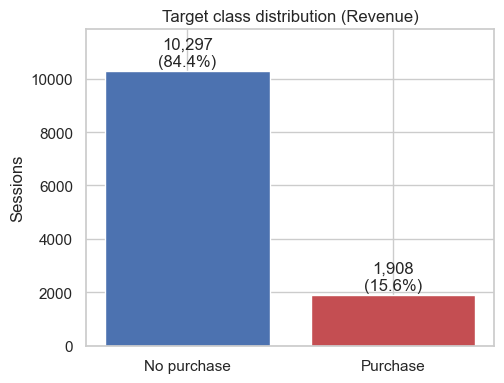

In [7]:
order = ["No purchase", "Purchase"] # ordering our target class for the sake of consistency across plots
cnt = df["Revenue"].map({False:"No purchase", True:"Purchase"}).value_counts().reindex(order) # maps our revenue (0, 1) values to either no purchase or purchase, counts # sessions per class, then indexes based on order
fig, ax = plt.subplots(figsize=(5.2, 4))
bars = ax.bar(order, cnt.values, color=["#4C72B0", "#C44E52"])
for b, v in zip(bars, cnt.values):
    ax.text(b.get_x()+b.get_width()/2, v+80, f"{v:,}\n({v/len(df):.1%})", ha="center", va="bottom") # bar labels
ax.set_ylabel("Sessions"); ax.set_title("Target class distribution (Revenue)")
ax.set_ylim(0, cnt.max()*1.15); plt.tight_layout(); plt.show()

Next, let's take a look at the distribution of product related browsing time as well as duration per page based on user conversion.

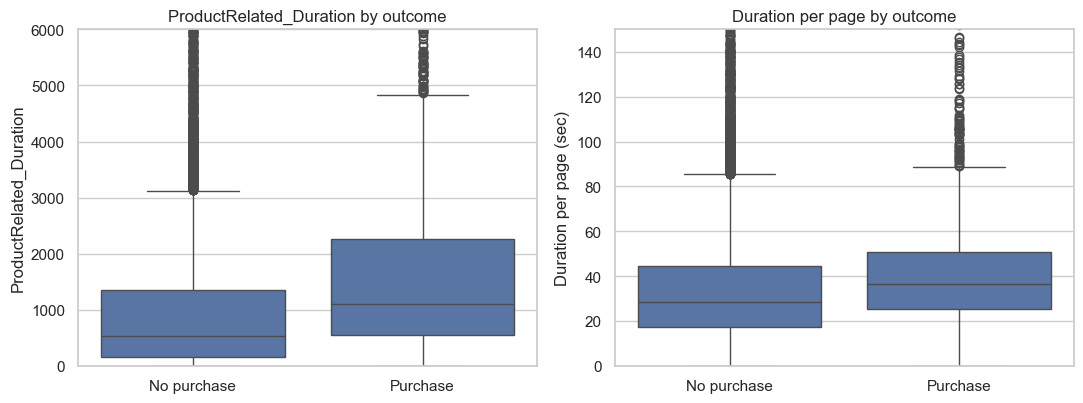

In [8]:
df_e = df.assign(Revenue_lbl=df["Revenue"].map({False:"No purchase", True:"Purchase"}),
                 dur_per_page=dur_per_page)   # reuse the per-page duration from the outlier analysis
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.boxplot(data=df_e, x="Revenue_lbl", y="ProductRelated_Duration", ax=axes[0])
axes[0].set_ylim(0, 6000); axes[0].set_title("ProductRelated_Duration by outcome")
sns.boxplot(data=df_e, x="Revenue_lbl", y="dur_per_page", ax=axes[1])
axes[1].set_ylim(0, 150); axes[1].set_ylabel("Duration per page (sec)"); axes[1].set_title("Duration per page by outcome")
for a in axes: a.set_xlabel("")
plt.tight_layout(); plt.show()

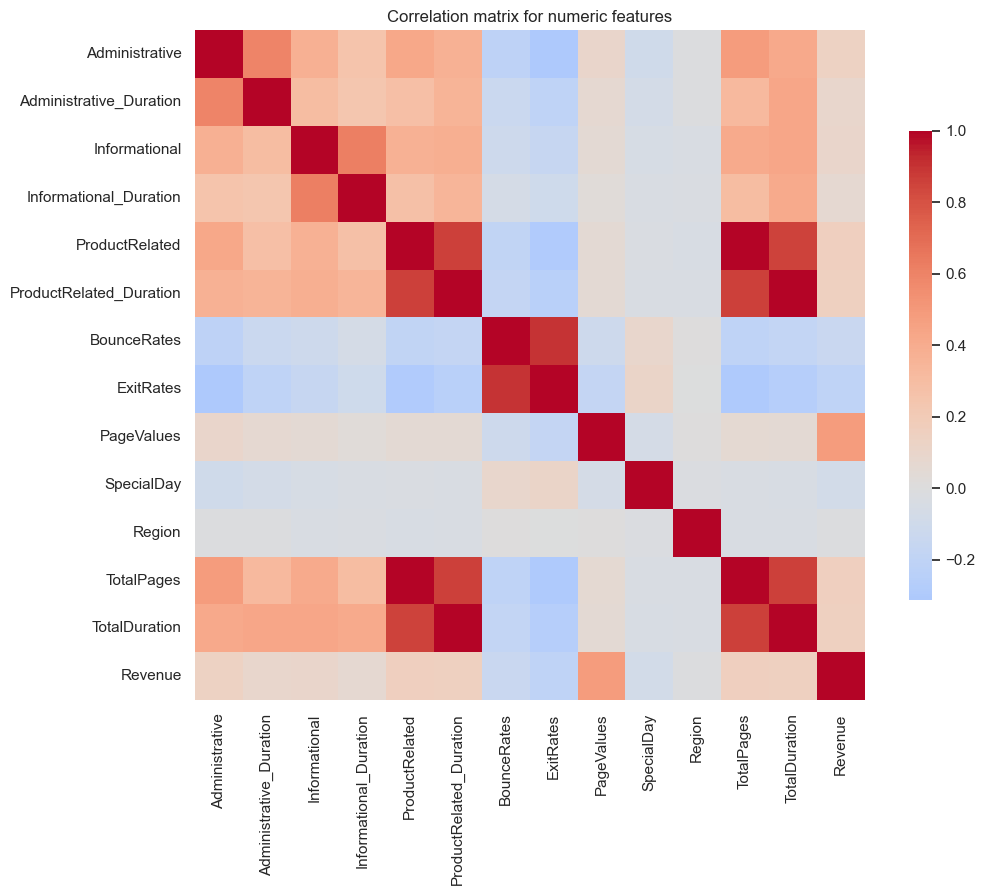

Most correlated pairs:
 ProductRelated           TotalPages                 0.997
ProductRelated_Duration  TotalDuration              0.994
BounceRates              ExitRates                  0.902
ProductRelated           ProductRelated_Duration    0.860
ProductRelated_Duration  TotalPages                 0.860
dtype: float64


In [9]:
num = df.select_dtypes("number").assign(Revenue=df["Revenue"].astype(int))
# deselect operating system, browser, and traffic type columns, which are categorical but encoded as numbers
num = num.drop(columns=["OperatingSystems", "Browser", "TrafficType"])
corr = num.corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink":.7}) # set white as default center, square cells, smaller legend
plt.title("Correlation matrix for numeric features"); plt.tight_layout(); plt.show()
upper = corr.abs().where(np.triu(np.ones(corr.shape),1).astype(bool)).stack().sort_values(ascending=False) # triu returns the upper triangle of an array order
# this gets the upper triangle of correlation matrix, takes absolute values, stacks them into a Series, and sorts it all by correlation strength
print("Most correlated pairs:\n", upper.head(5).round(3))

To no surprise, the total number of pages visited is highly correlated with the number of products viewed, the time spent browsing products, and the total browsing time; bounce and exit rates are also strongly correlated with one another. `PageValues` is by far the predictor most correlated with the target.

These correlations are relationships that can be somewhat expected, such as bounce vs exit, or a subset of duration vs total duration. Regularization in our logistic models and the nature of our trees both cope with it, we won't bother with PCA as it'd also obscure the per-feature interpretability we want for deriving business insights.

Let's see if conversion by month, visitor type, weekend, and the presence of page value affect the conversion rate.

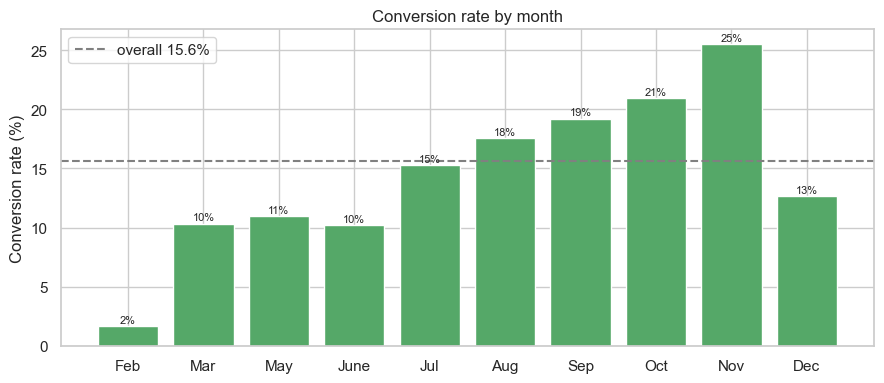

In [10]:
month_order = ["Feb","Mar","Apr","May","June","Jul","Aug","Sep","Oct","Nov","Dec"]
present = [m for m in month_order if m in df["Month"].unique()]
mconv = df.groupby("Month")["Revenue"].mean().reindex(present) # conversion rate by month, reindexed to our desired month order but only including months present in the data to avoid NaNs bc we're missing Jan and Apr
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(mconv.index, mconv.values*100, color="#55A868") # convert to percentages for better interpretability in the plot
ax.axhline(df["Revenue"].mean()*100, ls="--", color="grey", label=f"overall {df['Revenue'].mean()*100:.1f}%") # horizontal line for the overall conversion rate
for b, v in zip(bars, mconv.values*100):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f"{v:.0f}%", ha="center", fontsize=8) # bar labels with percentage formatting
ax.set_ylabel("Conversion rate (%)"); ax.set_title("Conversion rate by month"); ax.legend()
plt.tight_layout(); plt.show()

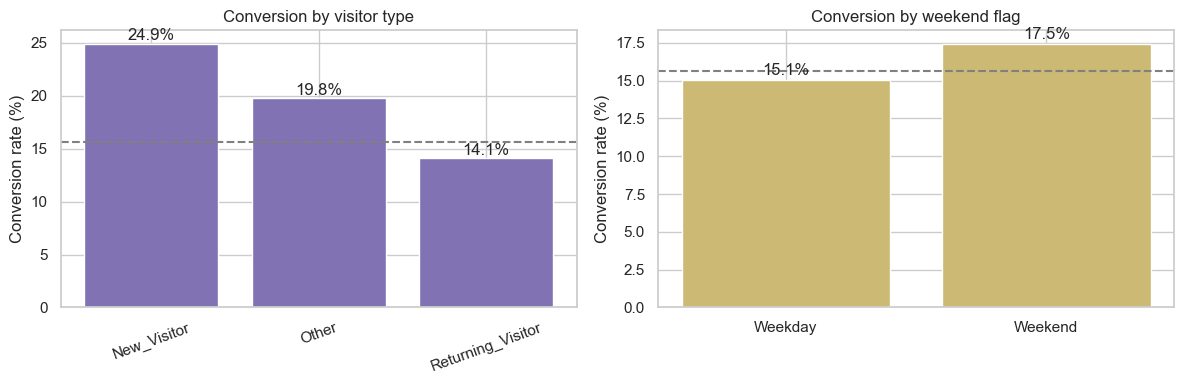

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vconv = df.groupby("VisitorType")["Revenue"].mean()*100 # visitor type conversion rate in percentage
axes[0].bar(vconv.index, vconv.values, color="#8172B3")
axes[0].axhline(df["Revenue"].mean()*100, ls="--", color="grey") # horizontal line for overall conversion rate
for i, v in enumerate(vconv.values): axes[0].text(i, v+0.3, f"{v:.1f}%", ha="center")
axes[0].set_title("Conversion by visitor type"); axes[0].set_ylabel("Conversion rate (%)"); axes[0].tick_params(axis="x", rotation=20)

wconv = df.groupby("Weekend")["Revenue"].mean()*100
axes[1].bar(["Weekday","Weekend"], wconv.values, color="#CCB974")
axes[1].axhline(df["Revenue"].mean()*100, ls="--", color="grey") # horizontal line for overall conversion rate
for i, v in enumerate(wconv.values): axes[1].text(i, v+0.3, f"{v:.1f}%", ha="center")
axes[1].set_title("Conversion by weekend flag"); axes[1].set_ylabel("Conversion rate (%)")
plt.tight_layout(); plt.show()

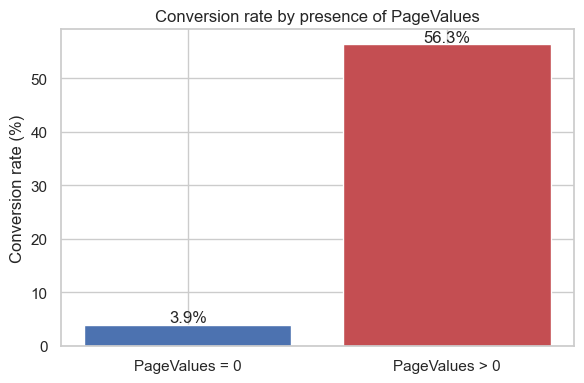

22.4% of sessions have PageValues > 0, and they convert at 56.3% vs 3.9% when PageValues = 0.


In [12]:
pv_pos = df["PageValues"] > 0 # filter positive PageValues sessions
seg = pd.Series({"PageValues = 0": df.loc[~pv_pos,"Revenue"].mean()*100,
                 "PageValues > 0": df.loc[pv_pos,"Revenue"].mean()*100}) # mean conversion rate for each segment
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(seg.index, seg.values, color=["#4C72B0","#C44E52"])
for b, v in zip(bars, seg.values): ax.text(b.get_x()+b.get_width()/2, v+0.5, f"{v:.1f}%", ha="center") # bar labels
ax.set_ylabel("Conversion rate (%)"); ax.set_title("Conversion rate by presence of PageValues")
plt.tight_layout(); plt.show()
print(f"{pv_pos.mean():.1%} of sessions have PageValues > 0, and they convert at {df.loc[pv_pos,'Revenue'].mean():.1%} vs {df.loc[~pv_pos,'Revenue'].mean():.1%} when PageValues = 0.")

So newcomers are most likely to spend money, those who actually spend time on pages that Google Analytics deems to have value are also more likely to convert, and users are more likely to spend money in the Fall months preceding December rather than during the Winter or Spring.

Let's start with some preprocessing, engineering, and modelling. 

For modelling we'll need to use a stratified split to preserve the class ratio in both partitions, and we'll also need two differently-encoded views of the data. The logistic models (baseline logit and LASSO) need scaled, standardized numeric features, while the tree models (RF, XGBoost) don't need anything of the sort. We'll thus set up two `ColumnTransformer` pipelines we can reuse for the two types of models.

Note that one-hot encoding the categoricals will lead to the presence of many more columns in the new dataset.

In [13]:
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)
cat_cols = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"] # our categorical columns for one-hot encoding
for c in cat_cols:
    df[c] = df[c].astype(str) # cast our categoricals to strings

y = df["Revenue"]
X = df.drop(columns=["Revenue"])
num_cols = [c for c in X.columns if c not in cat_cols]

# 80-20 stratified split using our global seed for reproducibility
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=global_seed)
print(f"Train {X_tr.shape} (pos {y_tr.mean():.1%}), \nTest {X_te.shape} (pos {y_te.mean():.1%})") # make sure our splits are proportionate

ohe = lambda: OneHotEncoder(handle_unknown="ignore", sparse_output=False) # lambda function for our one-hot encoder to avoid sparse matrices in the pipeline
# raw pipeline for tree-based models (one-hot encode factors, no scaling of numerics)
pre_raw    = ColumnTransformer([("num", "passthrough", num_cols), ("cat", ohe(), cat_cols)])
# scaled pipeline for the logistic models
pre_scaled = ColumnTransformer([("num", StandardScaler(), num_cols), ("cat", ohe(), cat_cols)])
print(f"{len(num_cols)} numeric and {len(cat_cols)} categorical predictors")

Train (9764, 19) (pos 15.6%), 
Test (2441, 19) (pos 15.6%)
13 numeric and 6 categorical predictors


Let's take a quick look at how significantly our column count has changed after our one-hot encoding.

In [14]:
X_tr_transformed = pre_raw.fit_transform(X_tr)
print(f"Shape before pipeline: {X_tr.shape}")
print(f"Shape AFTER pipeline: {X_tr_transformed.shape}")

Shape before pipeline: (9764, 19)
Shape AFTER pipeline: (9764, 75)


So we leapt from 19 to 75 columns. Next we randomly oversample the positive class in our training set only, avoiding messing with our test set to avoid data leakage. This balanced set is used to fit the baseline logit (which has no built-in imbalance handling). The LASSO and tree models will instead use `class_weight`/`scale_pos_weight` inside cross-validation, which keeps the resampling out of the CV folds and avoids leakage across folds.

In [15]:
def oversample(Xd, yd, seed=global_seed): # helper function for random oversampling
    d = Xd.copy(); d["_y"] = yd.values # combine X and y for resampling, with a temporary column name of _y for the target
    pos, neg = d[d._y == 1], d[d._y == 0] # separate the combined data into positive and negative classes
    up = resample(pos, replace=True, n_samples=len(neg), random_state=seed) # oversample the positive class with replacement to match the number of negatives
    out = pd.concat([neg, up]).sample(frac=1, random_state=seed) # combine the oversampled positives with the original negatives, then shuffle the resulting data
    return out.drop(columns="_y"), out["_y"] # returns separate X and y after oversampling, with the temporary _y column dropped

X_bal, y_bal = oversample(X_tr, y_tr) # oversample our training data
print(f"Oversampled training set: {X_bal.shape} (pos {y_bal.mean():.1%}), \nTest {X_te.shape} (pos {y_te.mean():.1%})")

Oversampled training set: (16476, 19) (pos 50.0%), 
Test (2441, 19) (pos 15.6%)


Looks like our oversampling for the training set was successful!

We can now begin our modelling. We'll make a single set of 10-folds for CV using our global seed so every grid search sees the same partitions, and we'll also use a small helper to score each fitted model on the held-out test set. Because of the heavy class imbalance, we'll use F1, precision, recall, PR-AUC, and ROC-AUC for model evaluation rather than accuracy.

In [16]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=global_seed)  # same 10 folds for every model
results = {}
test_proba = {} # store positive-class probabilities for the curves later

def evaluate_proba(name, proba, thresh=0.5): # default threshold = 0.5 but can be tweaked with an arg
    proba = np.asarray(proba); pred = (proba >= thresh).astype(int) # convert probabilities to binary predictions based on the threshold
    results[name] = {"F1": f1_score(y_te, pred), "Precision": precision_score(y_te, pred), # create a dictionary of metrics for a given model
                     "Recall": recall_score(y_te, pred),
                     "PR_AUC": average_precision_score(y_te, proba),
                     "ROC_AUC": roc_auc_score(y_te, proba)}
    test_proba[name] = proba # probabilities for the positive class, which we'll need for the curves
    print(f"{name}:  F1={results[name]['F1']:.3f}  Precision={results[name]['Precision']:.3f} Recall={results[name]['Recall']:.3f}  PR-AUC={results[name]['PR_AUC']:.3f} ROC-AUC={results[name]['ROC_AUC']:.3f}")

Our first model will be a baseline unregularized logistic regression, which can be treated as an easily interpretable reference point. Let's train it on our oversampled training set.

In [17]:
logit_base = Pipeline([("pre", pre_scaled),
                       ("clf", LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000)) # no regularization for the baseline, max_iter set higher to ensure convergence given the larger sample size after oversampling
                       ]).fit(X_bal, y_bal)  # lbfgs is the default sklearn solver for logistic regression
evaluate_proba("Logistic (baseline)", logit_base.predict_proba(X_te)[:, 1])

Logistic (baseline):  F1=0.602  Precision=0.495 Recall=0.770  PR-AUC=0.644 ROC-AUC=0.899


Next, we'll use LASSO with a lambda that yields minimal CV error. It's nice that LASSO also performs embedded feature selection. We'll perform a grid-search on the inverse regularization strength `C` over 50 values, and select the value that minimizes cross-validated log-loss or deviance. This basically works like R glmnet's `lambda.min`. Passing `class_weight="balanced"` will the imbalance inside CV without us needing to resample the folds ourselves this time.

In [18]:
lasso_grid = GridSearchCV(
    Pipeline([("pre", pre_scaled),
              ("clf", LogisticRegression(penalty="l1", solver="liblinear", max_iter=5000, # using liblinear solver since it's the only one that supports LASSO in sklearn, passing same iter as before
                                         class_weight="balanced", random_state=global_seed))]), # class weight balanced to account for class imbalance, global seed again
    {"clf__C": np.logspace(-3, 1, 50)}, # C is the inverse of regularization strength
    scoring="neg_log_loss", cv=cv, n_jobs=-1).fit(X_tr, y_tr) # selects C that minimizes cross-validated error using negative log loss
print("Best C:", lasso_grid.best_params_["clf__C"])
evaluate_proba("LASSO (lambda.min)", lasso_grid.best_estimator_.predict_proba(X_te)[:, 1]) # evaluate the best LASSO model on the test set

Best C: 0.15998587196060574
LASSO (lambda.min):  F1=0.608  Precision=0.503 Recall=0.767  PR-AUC=0.646 ROC-AUC=0.900


Now we'll move onto my preferred version LASSO: the equivalent of R glmnet's LASSO using `lambda.1se`. The `lambda.1se` rule picks the most parsimonious model whose CV deviance is within one standard error of the best, which yields a more parsimonious model with fewer features that's easier to read while often preserving most of the performance of LASSO with `lambda.min`. We'll need our own implementation here as sklearn doesn't have an equivalent built in. 

In [19]:
cvr  = pd.DataFrame(lasso_grid.cv_results_) # cross-validation results from our earlier grid search, which we'll use to find the 1-SE lambda
best = cvr["mean_test_score"].idxmax() # index of the best mean CV score
# SE = std / sqrt(n), n being the number of folds in our cross-validation in this case
se   = cvr.loc[best, "std_test_score"] / np.sqrt(cv.get_n_splits()) # calculate the SE of the mean CV score
within = cvr["mean_test_score"] >= cvr.loc[best, "mean_test_score"] - se # our 1se band
C_1se  = cvr.loc[within, "param_clf__C"].min() # min C (max lambda) in the 1se band
dev_min = -cvr.loc[best, "mean_test_score"] # flip the log-loss sign to get the deviance back in positive terms for easier interpretation
print(f"C (lambda.min) = {lasso_grid.best_params_['clf__C']:.4g} (mean CV deviance = {dev_min:.3f} with a standard error of {se:.3f})")
print(f"1-SE band yields a CV error of {dev_min:.3f} + {se:.3f} = {dev_min + se:.3f}")
print(f"Corresponding to C (lambda.1se) = {C_1se:.4g}")

lasso_1se = clone(lasso_grid.best_estimator_).set_params(clf__C=C_1se).fit(X_tr, y_tr) # refit a model using the lambda.1se value of C
n_min = (lasso_grid.best_estimator_.named_steps["clf"].coef_[0] != 0).sum() # number of features retained in the lambda.min model
n_1se = (lasso_1se.named_steps["clf"].coef_[0] != 0).sum()
print(f"Features retained: lambda.min = {n_min}  vs  lambda.1se = {n_1se}")
evaluate_proba("LASSO (lambda.1se)", lasso_1se.predict_proba(X_te)[:, 1]) # evaluate the lambda.1se model on the test set

C (lambda.min) = 0.16 (mean CV deviance = 0.441 with a standard error of 0.011)
1-SE band yields a CV error of 0.441 + 0.011 = 0.452
Corresponding to C (lambda.1se) = 0.01389
Features retained: lambda.min = 34  vs  lambda.1se = 12
LASSO (lambda.1se):  F1=0.627  Precision=0.537 Recall=0.751  PR-AUC=0.649 ROC-AUC=0.901


As expected, our more parsimonious model created using lambda.1se actually generalizes better and yields better results on the test set.

Now we'll move onto tree-based models. We'll start with a random forest, which can be fit directly on the raw (unscaled, one-hot) data. We tune the number of trees and maximum depth with F1-scored cross-validation; `class_weight="balanced"` once again handles the imbalance as it did in LASSO without needing manual oversampling.

In [20]:
rf_grid = GridSearchCV(
    Pipeline([("pre", pre_raw),
              ("clf", RandomForestClassifier(class_weight="balanced",
                                             random_state=global_seed, n_jobs=-1))]),
    {"clf__n_estimators": [300, 500], "clf__max_depth": [None, 12, 20]},
    scoring="f1", cv=cv, n_jobs=-1).fit(X_tr, y_tr)
print("Best params:", rf_grid.best_params_)
evaluate_proba("Random forest", rf_grid.best_estimator_.predict_proba(X_te)[:, 1])

Best params: {'clf__max_depth': 12, 'clf__n_estimators': 300}
Random forest:  F1=0.669  Precision=0.588 Recall=0.775  PR-AUC=0.688 ROC-AUC=0.920


And our final standalone model, XGBoost, aka gradient-boosted trees, which are known to do well on data with innate class imbalances. This time, instead of `class_weigh`, we'll pass `scale_pos_weight` = (negatives / positives) from the original training set so the loss up-weights our minority class (purchases), and tune our hyperparameters based on F1-scored CV.

In [21]:
spw = (y_tr == 0).sum() / (y_tr == 1).sum() # neg:pos ratio for scale_pos_weight
xgb = XGBClassifier(objective="binary:logistic", eval_metric="logloss", # binary classification with log loss evaluation metric for consistency with our logistic regression models
                    tree_method="hist", scale_pos_weight=spw, # up-weights the positive class
                    random_state=global_seed, n_jobs=1) # n_jobs set to avoid nested parallel processing issues with GridSearchCV
xgb_grid = GridSearchCV(
    Pipeline([("pre", pre_raw), ("clf", xgb)]), # raw data, xgboost classifier
    {"clf__n_estimators": [500, 1000, 1500, 2000], # ranges for number of trees
     "clf__max_depth": [3, 4, 5, 6, 7], # depth ranges
     "clf__learning_rate":[0.01, 0.02, 0.05], # learning rate values
     "clf__subsample": [0.9]}, # row subsampling for regularization
    scoring="f1", cv=cv, n_jobs=-1).fit(X_tr, y_tr) # optimize based on F1 score to balance precision and recall, same CV and parallel processing setup as before
print("Best params:", xgb_grid.best_params_)
evaluate_proba("XGBoost", xgb_grid.best_estimator_.predict_proba(X_te)[:, 1]) # evaluate the best XGBoost model on the test set

Best params: {'clf__learning_rate': 0.02, 'clf__max_depth': 5, 'clf__n_estimators': 1500, 'clf__subsample': 0.9}
XGBoost:  F1=0.693  Precision=0.618 Recall=0.791  PR-AUC=0.735 ROC-AUC=0.927


Lastly, we'll put together everything we've done so far into a simple soft-voting ensemble that averages the predicted probabilities of our three strongest learners so far, namely LASSO, our random forest, and XGBoost, to see if the different methods working in synergy can yield anything more interesting. What we're mostly interested in here is seeing if we can combine the strengths of the LASSO with the strengths of tree-based models. XGBoost is noticeably better than the other models we've tried so far, though, so this seems unlikely. 

In [22]:
voter = VotingClassifier(
    estimators=[("lasso", clone(lasso_grid.best_estimator_)), # clone the best estimators from our previous grid searches to avoid refitting them
                ("rf", clone(rf_grid.best_estimator_)),
                ("xgb", clone(xgb_grid.best_estimator_))],
    voting="soft", n_jobs=-1).fit(X_tr, y_tr)
evaluate_proba("Soft-vote ensemble", voter.predict_proba(X_te)[:, 1])

Soft-vote ensemble:  F1=0.673  Precision=0.591 Recall=0.780  PR-AUC=0.726 ROC-AUC=0.926


Not exactly a shocker that the results are poorer than those of XGBoost, though it does improve upon the results from the other two models. Let's now compare all of our models and rank them by F1, again due to the heavy class imbalance in the original data.

In [23]:
res = pd.DataFrame(results).T.sort_values("F1", ascending=False)
res.round(3)

,F1,Precision,Recall,PR_AUC,ROC_AUC
XGBoost,0.693,0.618,0.791,0.735,0.927
Soft-vote ensemble,0.673,0.591,0.780,0.726,0.926
Random forest,0.669,0.588,0.775,0.688,0.920
LASSO (lambda.1se),0.627,0.537,0.751,0.649,0.901
LASSO (lambda.min),0.608,0.503,0.767,0.646,0.900
Logistic (baseline),0.602,0.495,0.770,0.644,0.899


The confusion matrices make the precision/recall trade-off concrete at the default 0.5 threshold.

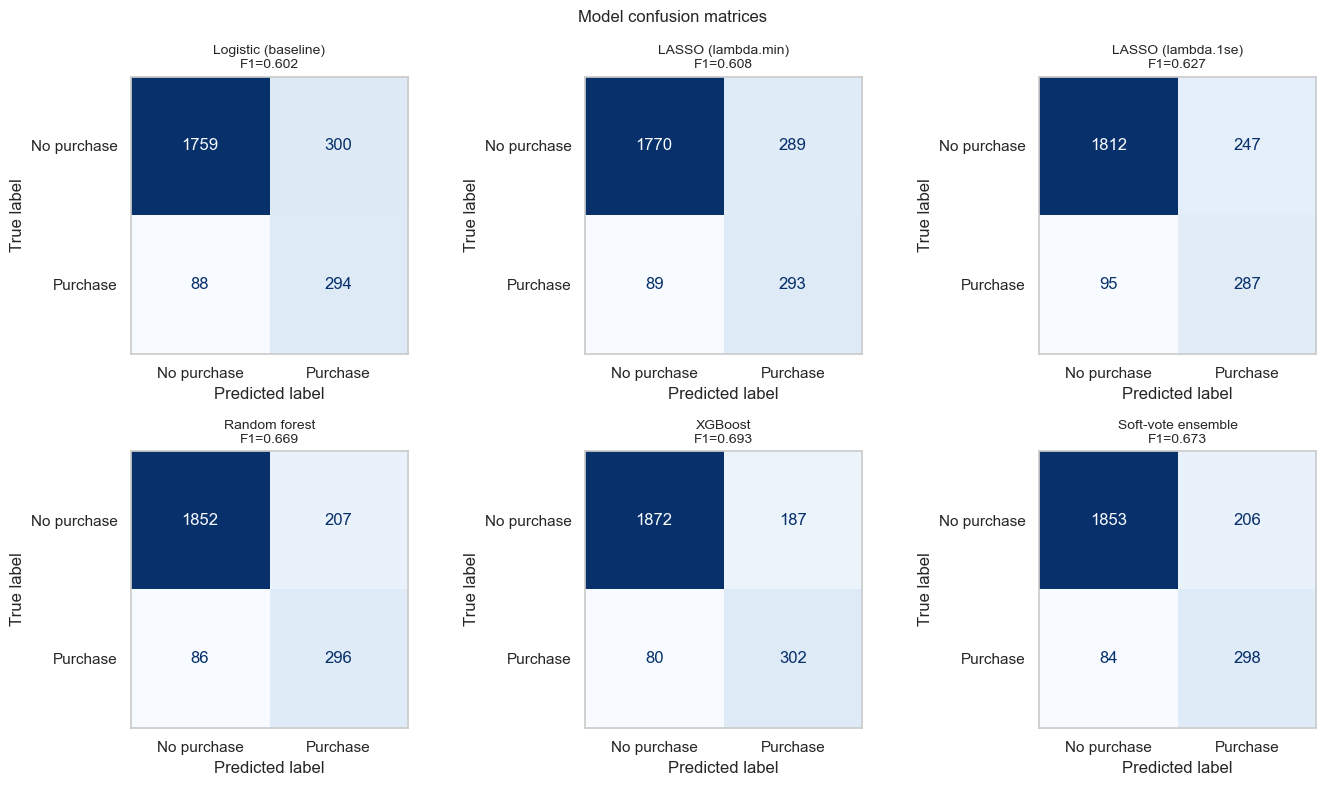

In [24]:
names = list(results.keys())
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, name in zip(axes.ravel(), names):
    pred = (test_proba[name] >= 0.5).astype(int)
    cm = confusion_matrix(y_te, pred)
    ConfusionMatrixDisplay(cm, display_labels=["No purchase", "Purchase"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.grid(False)
    ax.set_title(f"{name}\nF1={results[name]['F1']:.3f}", fontsize=10)
# only needed the following when we didn't have an ensemble, which would have left us with an empty subplot
# for ax in axes.ravel()[len(names):]: ax.axis("off") 
fig.suptitle("Model confusion matrices", fontsize=12)
plt.tight_layout(); plt.show()

Let's also make a normalized version of our confusion matrices.

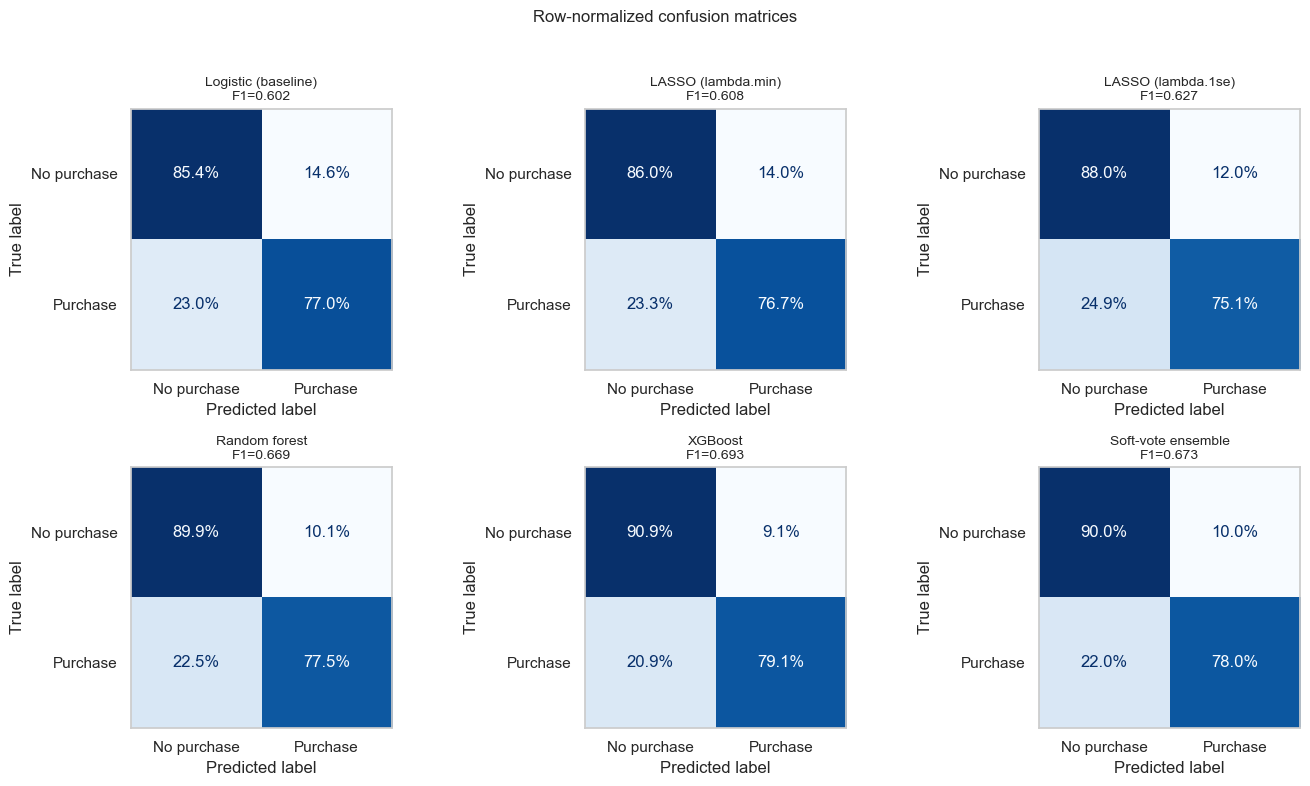

In [25]:
# normalized percentage-based confusion matrices for better visual comparison across models, with clearer labels and no grid for easier readability
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, name in zip(axes.ravel(), names):
    pred = (test_proba[name] >= 0.5).astype(int)
    cm = confusion_matrix(y_te, pred, normalize="true")   # row-normalized
    ConfusionMatrixDisplay(cm, display_labels=["No purchase", "Purchase"]).plot(ax=ax, colorbar=False, cmap="Blues", values_format=".1%")
    ax.grid(False)
    ax.set_title(f"{name}\nF1={results[name]['F1']:.3f}", fontsize=10)
# for ax in axes.ravel()[len(names):]: ax.axis("off")
fig.suptitle("Row-normalized confusion matrices", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

Because we care about ranking sessions by purchase likelihood, the ROC and precision-recall curves help us evaluate performance more visually as well.

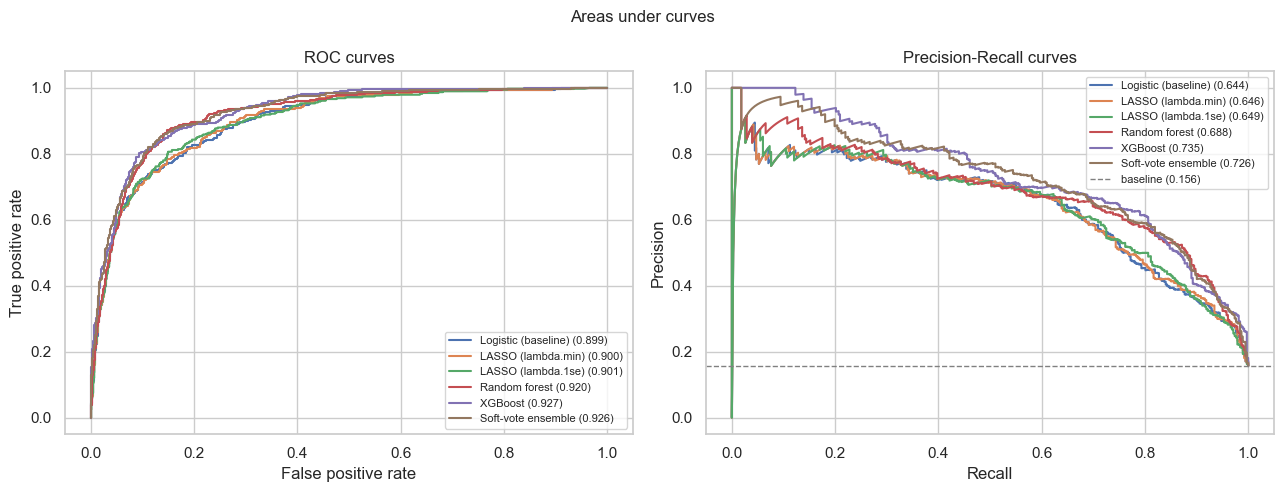

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in names:
    fpr, tpr, _ = roc_curve(y_te, test_proba[name]) # false positive rate, true positive rate, and thresholds for the ROC curve
    axes[0].plot(fpr, tpr, label=f"{name} ({results[name]['ROC_AUC']:.3f})") # auc in legend
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves"); axes[0].legend(fontsize=8, loc="lower right")

for name in names:
    prec, rec, _ = precision_recall_curve(y_te, test_proba[name])
    axes[1].plot(rec, prec, label=f"{name} ({results[name]['PR_AUC']:.3f})")
axes[1].axhline(y_te.mean(), ls="--", color="grey", lw=1, label=f"baseline ({y_te.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves"); axes[1].legend(fontsize=8, loc="upper right")
fig.suptitle("Areas under curves", fontsize=12)
plt.tight_layout(); plt.show()

Three of our models, namely our preferred LASSO (`lambda.1se`), random forest, and XGBoost models all gain some form of feature importance whether through coefficients or feature importances from splits. Let's take a look at these quickly.

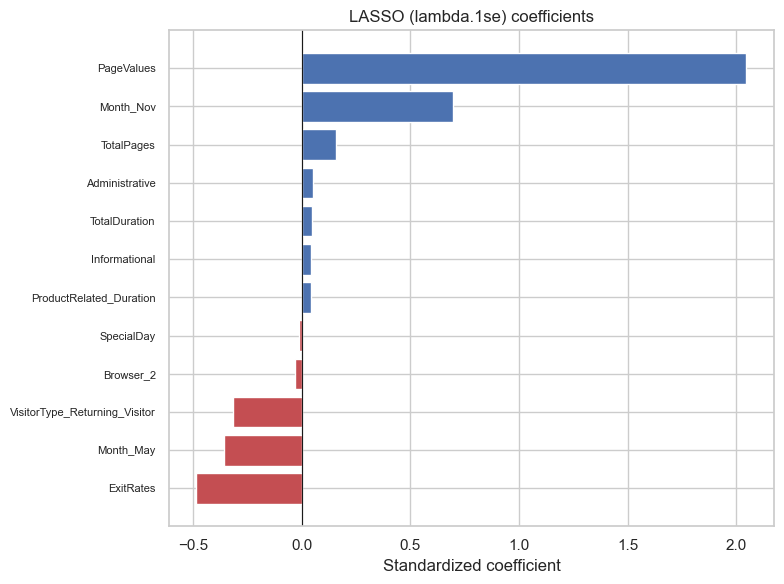

num__ExitRates                       -0.483660
cat__Month_May                       -0.358363
cat__VisitorType_Returning_Visitor   -0.315601
cat__Browser_2                       -0.030714
num__SpecialDay                      -0.013216
num__ProductRelated_Duration          0.041504
num__Informational                    0.045408
num__TotalDuration                    0.046206
num__Administrative                   0.050895
num__TotalPages                       0.157188
cat__Month_Nov                        0.697336
num__PageValues                       2.046609
dtype: float64

In [27]:
coef = pd.Series(lasso_1se.named_steps["clf"].coef_[0],
                 index=lasso_1se.named_steps["pre"].get_feature_names_out()) # extract our standardized coefficients from the lambda.1se model with feature names from the pipeline
coef_nonzero = coef[coef != 0].sort_values()

top = pd.concat([coef_nonzero.head(8), coef_nonzero.tail(8)]).drop_duplicates()
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(top)), top.values, # sort by magnitude of coefficients for better visualization
        color=["#C44E52" if v < 0 else "#4C72B0" for v in top.values]) # red for negative, blue for positive
ax.set_yticks(range(len(top)))
ax.set_yticklabels([t.replace("num__","").replace("cat__","") for t in top.index], fontsize=8) # trim the feature names for better readability
ax.axvline(0, color="k", lw=0.8)
ax.set_title("LASSO (lambda.1se) coefficients")
ax.set_xlabel("Standardized coefficient"); plt.tight_layout(); plt.show()
coef_nonzero

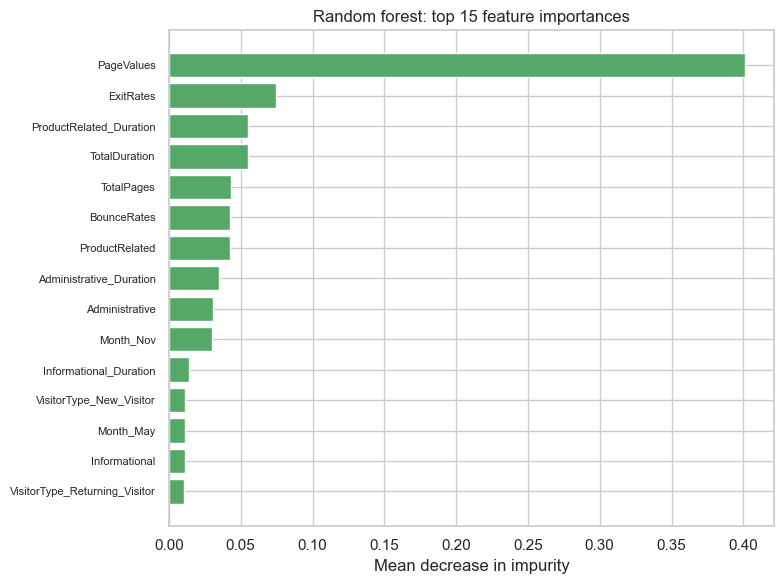

In [28]:
rf_clf  = rf_grid.best_estimator_.named_steps["clf"]
rf_feat = rf_grid.best_estimator_.named_steps["pre"].get_feature_names_out()
rf_imp  = pd.Series(rf_clf.feature_importances_, index=rf_feat).sort_values(ascending=False).head(15) # top 15 features by importance from the random forest model
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(rf_imp))[::-1], rf_imp.values, color="#55A868") # reverse importance sort
ax.set_yticks(range(len(rf_imp))[::-1])
ax.set_yticklabels([t.replace("num__","").replace("cat__","") for t in rf_imp.index], fontsize=8) # tidy up feature names
ax.set_title("Random forest: top 15 feature importances"); ax.set_xlabel("Mean decrease in impurity") # decrease in impurity calculated by the Gini index for each feature, averaged across all trees in the forest
plt.tight_layout(); plt.show()

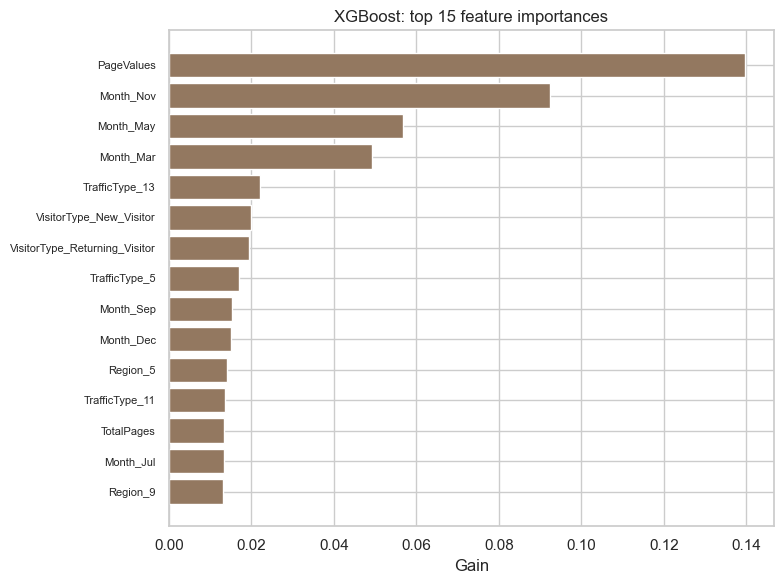

In [29]:
xgb_clf  = xgb_grid.best_estimator_.named_steps["clf"]
xgb_feat = xgb_grid.best_estimator_.named_steps["pre"].get_feature_names_out()
xgb_imp  = pd.Series(xgb_clf.feature_importances_, index=xgb_feat).sort_values(ascending=False).head(15) # top 15 features by importance from the XGBoost model
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(xgb_imp))[::-1], xgb_imp.values, color="#937860") # bars sorted by importance, so reverse the y-axis to match the sorted order
ax.set_yticks(range(len(xgb_imp))[::-1]) # y-ticks in reverse order
ax.set_yticklabels([t.replace("num__","").replace("cat__","") for t in xgb_imp.index], fontsize=8) # remove the pipeline prefixes from feature names
ax.set_title("XGBoost: top 15 feature importances"); ax.set_xlabel("Gain") # gain calculates the improvement in accuracy brought by a feature to the branches it is on, averaged across all trees in the model
plt.tight_layout(); plt.show()

Across all three of our top models, we can observe that `PageValues` is the strongest predictor by a wide margin in every model. As we found during our EDA, sessions that hit a value-bearing page convert at a much higher rate of approximately 56* versus under 4% otherwise. There's a catch though, namely that `PageValues` is a Google Analytics metric built from past transactions, so a high value kind of just says the session already got close to buying. It's nice to have for catching high-intent sessions while they're live, but it isn't something that the store would be able to affect directly, so it's more of a a detection signal for a coming purchase rather than a target that can be tweaked to improve purchase rates.

On the other hand exit rate, along with the related bounce rate, can show where people are leaving the website from, which is where changes to the webstore itself are worth the effort.

Season and visitor type help too, but not equally. For example, we can see that November conversion is more than double the spring rate, which is a solid guide as to when to demand converts. New visitors convert at almost twice the rate of returning ones, but they probably arrive through specialized channels that already convey high purchasing intent (i.e. clicking on referral links, search results, and advertisements, so they were probably already interested in the store's products), so it could instead be read as more of a reason to prioritise new-visitor sessions when they show up, instead of suggesting that the store should be buying more new traffic for increased conversions.

On the modelling side, XGBoost came out on top by a noticeable margin compared to differences in performance across the other models, with the ensemble model just behind (but it has lower performance that XGBoost, one of its members, so its of no effective use for us), but the overall gap over the linear models is small. The 12-feature `lambda.1se` LASSO already beats the unregularized baseline, so a compact, readable model gets most of the way there, which interpretability much nicer.

At the end of the day, for a similar webstore selling online products similar to what this store sells (which, admittedly, we're unaware of), it's largely safe to use `PageValues` to catch high-intent sessions in real time, use exit and bounce rates to find where the funnel leaks, lean into the autumn run-up, and prioritise new visitors when they arrive, but some A/B testing could go a long way in further identifying what changes to make to the store itself. 